# Avengers: Endgame Tweet Sentiment and Emotion Analysis Using NLP

**Natural Language Processing (NLP)** is a subfield of artificial intelligence and machine
learning that focuses on the interaction between computers and human language. It aims to
enable computers to understand, interpret, and generate natural language text or speech.

### Step 1: Import the necessary libraries

In this NLP task, we will mostly be using NLTK (Natural Language Toolkit). NLTK is a
powerful and flexible library for NLP tasks. It is widely used in natural language processing
(NLP) tasks. Many basic NLP tasks such as classification, tokenization, stemming, tagging,
parsing, and semantic reasoning are provided by this library. The complete library that used in
this Lab is shown below.

In [1]:
!python -m pip install nltk


[notice] A new release of pip available: 22.3 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Step 2: Collect and pre-process the data

An `tweets.csv` dataset is a dataset that contains 1000 data with 16 features. This is how
to load this dataset

In [3]:
dataset = pd.read_csv('tweets.csv')
dataset.head()

,screenName,text,favorited,favoriteCount,replyToSN,created,truncated,replyToSID,id,replyToUID,statusSource,retweetCount,isRetweet,retweeted,longitude,latitude
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,False,0,NaN,4/23/19 10:43,False,NaN,1.120000e+18,NaN,"<a href=""http://twitter.com/download/android"" ...",637,True,False,NaN,NaN
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",False,0,NaN,4/23/19 10:43,False,NaN,1.120000e+18,NaN,"<a href=""http://twitter.com/download/iphone"" r...",302,True,False,NaN,NaN
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,False,0,NaN,4/23/19 10:43,False,NaN,1.120000e+18,NaN,"<a href=""http://twitter.com/download/iphone"" r...",0,False,False,NaN,NaN
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,False,0,NaN,4/23/19 10:43,False,NaN,1.120000e+18,NaN,"<a href=""http://twitter.com/download/iphone"" r...",23781,True,False,NaN,NaN
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",False,0,NaN,4/23/19 10:43,False,NaN,1.120000e+18,NaN,"<a href=""http://twitter.com/download/iphone"" r...",13067,True,False,NaN,NaN


Here's an explanation of each feature in the dataset:
- `screenName`: The screen name (username) of the Twitter user who posted the tweet.

- `text`: The actual text content of the tweet.

- `favorited`: Indicates whether the tweet has been marked as a favorite by the user who posted it.

- `favoriteCount`: The number of times the tweet has been marked as a favorite by users.

- `replyToSN`: The screen name (username) of the Twitter user to whom the tweet is in reply to.

- `created`: The timestamp indicating when the tweet was created.

- `truncated`: Indicates whether the tweet text has been truncated (cut off) due to exceeding the character limit.

- `replyToSID`: The status ID of the tweet that the current tweet is replying to.

- `id`: The unique identifier of the tweet.

- `replyToUID`: The user ID of the Twitter user to whom the tweet is in reply to.

- `statusSource`: The source (client or application) used to post the tweet.

- `retweetCount`: The number of times the tweet has been retweeted by users.

- `isRetweet`: Indicates whether the tweet is a retweet.

- `retweeted`: Indicates whether the tweet is a retweet of another tweet.

- `longitude`: The longitude coordinate associated with the tweet's location, if available.

- `latitude`: The latitude coordinate associated with the tweet's location, if available.

In [4]:
dataset.shape

(1000, 16)

This dataset contains 1000 data and 16 features

In [5]:
dataset.isnull().sum()

screenName         0
text               0
favorited          0
favoriteCount      0
replyToSN        984
created            0
truncated          0
replyToSID       984
id                 0
replyToUID       984
statusSource       0
retweetCount       0
isRetweet          0
retweeted          0
longitude        999
latitude         999
dtype: int64

This dataset have 984, 984, 984, 999 and 999 missing values in `replyToSN`, `replyToSID`, `replyToUID`, `longitude`, and `latitude` respectively.

In [6]:
dataset = dataset.drop(['replyToSN', 'replyToSID','replyToUID','longitude','latitude'], axis=1)

dataset.head()

,screenName,text,favorited,favoriteCount,created,truncated,id,statusSource,retweetCount,isRetweet,retweeted
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,False,0,4/23/19 10:43,False,1.120000e+18,"<a href=""http://twitter.com/download/android"" ...",637,True,False
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",False,0,4/23/19 10:43,False,1.120000e+18,"<a href=""http://twitter.com/download/iphone"" r...",302,True,False
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,False,0,4/23/19 10:43,False,1.120000e+18,"<a href=""http://twitter.com/download/iphone"" r...",0,False,False
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,False,0,4/23/19 10:43,False,1.120000e+18,"<a href=""http://twitter.com/download/iphone"" r...",23781,True,False
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",False,0,4/23/19 10:43,False,1.120000e+18,"<a href=""http://twitter.com/download/iphone"" r...",13067,True,False


Since there is only 1000 data and the missing value is 984 and 999 so we directly drop the features.

In [7]:
dataset.isnull().sum()

screenName       0
text             0
favorited        0
favoriteCount    0
created          0
truncated        0
id               0
statusSource     0
retweetCount     0
isRetweet        0
retweeted        0
dtype: int64

Now there is no missing values in the dataset

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   screenName     1000 non-null   object 
 1   text           1000 non-null   object 
 2   favorited      1000 non-null   bool   
 3   favoriteCount  1000 non-null   int64  
 4   created        1000 non-null   object 
 5   truncated      1000 non-null   bool   
 6   id             1000 non-null   float64
 7   statusSource   1000 non-null   object 
 8   retweetCount   1000 non-null   int64  
 9   isRetweet      1000 non-null   bool   
 10  retweeted      1000 non-null   bool   
dtypes: bool(4), float64(1), int64(2), object(4)
memory usage: 58.7+ KB


In this dataset have 4 bool, 1 float64, 2 int64 and 4 object types

In [15]:
dataset2 = dataset[['screenName', 'text', 'favoriteCount']].copy()
dataset2.head()

,screenName,text,favoriteCount
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,0
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",0
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,0
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,0
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",0


Furthermore, from the total 10 features, we only need 3 most important which are
`screenName`, `text`, and `favoriteCount`, and saved within the new dataset2.
`screenName` will be used as an ID for each `text`, while `favoriteCount`is number of times the tweet has been marked as a favorite by users.

- Analyze the dataset

    There is only the favoriteCount feature that contain categorical feature and makes it easier forus to perform analysis. Therefore, we will create a plot to determine the count of each value in favoriteCount using the code below.

In [55]:
favoriteCount = dataset2['favoriteCount'].value_counts()
favoriteCount

0    982
1     12
2      4
6      1
4      1
Name: favoriteCount, dtype: int64

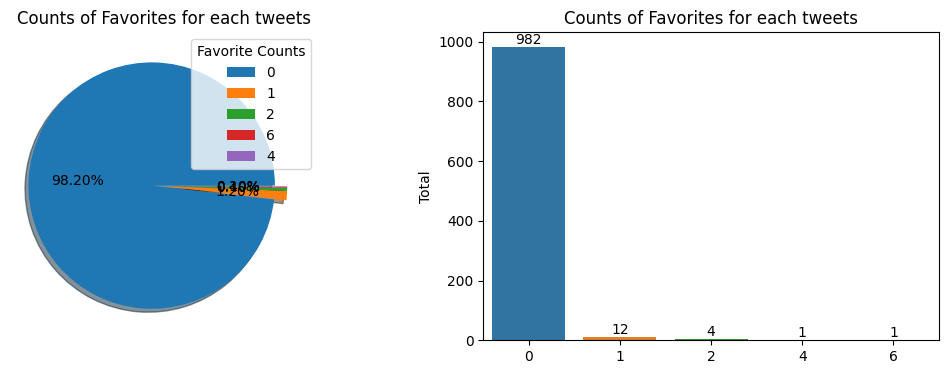

In [10]:
fig = plt.figure(figsize=(20, 4))
explode = (0.1, 0, 0, 0, 0) 
ax1 = fig.add_subplot(1, 3, 1)
ax1.pie(favoriteCount.values, explode=explode, shadow=True, autopct='%1.2f%%')
ax1.set_title("Counts of Favorites for each tweets")
ax1.legend(favoriteCount.keys(), title ="Favorite Counts")

ax2 = fig.add_subplot(1, 3, 2)
data = sns.barplot(x=favoriteCount.keys(), y=favoriteCount.values)
ax2.set_ylabel("Total")
ax2.set_title("Counts of Favorites for each tweets")
for i in data.patches:
    data.annotate(format(i.get_height(), '.0f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')

Based on the graph above, here's how we can interpret the favoriteCount feature for the given values:

- **982 tweets have 0 favorites**: These tweets have not been marked as a favorite by any user. It suggests that these tweets may not have gained much popularity or user engagement.

- **12 tweets have 1 favorite**: These tweets have been marked as a favorite by one user each. It indicates a small level of engagement, as a few users found these tweets interesting or liked them.

- **4 tweets have 2 favorites**: These tweets have been marked as a favorite by two users each. It shows a slightly higher level of engagement compared to the previous category.

- **1 tweet has 6 favorites**: This tweet has been marked as a favorite by six users. It indicates a relatively higher level of engagement and popularity, as a significant number of users found this tweet compelling or likable.

- **1 tweet has 4 favorites**: This tweet has been marked as a favorite by four users. It suggests a moderate level of engagement and popularity, as a few users found this tweet interesting or worth favoriting.

## Basic NLP operations

NLP techniques often involve various preprocessing steps, such as tokenization, stemming, part-of-speech
tagging, and syntactic parsing, to transform raw text data into a format that can be processed by machine
learning algorithms.
NLP has numerous practical applications in fields like customer service, information retrieval, content
analysis, language translation, and more. It plays a crucial role in enabling computers to understand and
interact with human language, making it an essential component of many AI systems.


In [16]:
dataset2['text']

0      RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...
1      RT @agntecarter: i’m emotional, sorry!!\r\n\r\...
2      saving these bingo cards for tomorrow \r\n©\r\...
3      RT @HelloBoon: Man these #AvengersEndgame ads ...
4      RT @Marvel: We salute you, @ChrisEvans! #Capta...
                             ...                        
995    Anyone interested for #AvengersEndgame 2D tick...
996    RT @Avengers: .@Renner4Real hits the mark! #Ha...
997    RT @MCU_Direct: The first NON-SPOILER #Avenger...
998    RT @Marvel: These guys. @AnthonyMackie @chrish...
999    RT @hmvtweets: WIN an #AvengersEndgame merch b...
Name: text, Length: 1000, dtype: object

### Convert to lowercase

Next, we will convert all characters in the text review into lowercase. Converting text to
lowercase is a common preprocessing step in NLP tasks. Lowercasing helps in normalizing the
text by reducing the complexity and variability of words. re treated as the same word.

In [17]:
lower_case = []
for words in dataset['text']:
    lower_case.append(str.lower(words))

In [18]:
lower_case[997]

'rt @mcu_direct: the first non-spoiler #avengersendgame critic reactions are here and nearly all are exceptionally positive, with many prais…'

### Remove punctuations

Similar to converting to lowercase. Removing punctuation is also important work to do
before analyzing text using NLP. Punctuation marks such as periods, commas, exclamation
marks, question marks, and quotation marks do not typically carry significant semantic
meaning on their own. By removing punctuation, we eliminate unnecessary noise from the text,
allowing the focus to be on the essential content.

In [19]:
import string
cleaned_text = []
for words_pos in lower_case:
    cleaned_text.append(words_pos.translate(str.maketrans('', '',string.punctuation)))

In [20]:
cleaned_text[997]

'rt mcudirect the first nonspoiler avengersendgame critic reactions are here and nearly all are exceptionally positive with many prais…'

### Tokenization

Tokenization is the process of breaking down a text into individual tokens or words. It
involves segmenting a sentence or document into meaningful units, such as words, subwords,
or characters. Tokenization forms the basis for various NLP tasks and allows the text to be
processed and analyzed at a granular level.

In [21]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
from nltk import word_tokenize

tokenized_words = []

for words in cleaned_text:
    tokenized_words.append(word_tokenize(words, 'english'))

In [23]:
tokenized_words[997]

['rt',
 'mcudirect',
 'the',
 'first',
 'nonspoiler',
 'avengersendgame',
 'critic',
 'reactions',
 'are',
 'here',
 'and',
 'nearly',
 'all',
 'are',
 'exceptionally',
 'positive',
 'with',
 'many',
 'prais…']

### Stop words removal

Stop words are common words (e.g., "the," "is," "and") that do not carry significant
meaning in a given context. In NLP, it is common to remove stop words from the text to reduce
noise and improve the efficiency of subsequent analysis. Stop word removal helps to focus on
more important content words and can enhance the performance of certain tasks like text
classification or topic modeling.

In [24]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
from nltk.corpus import stopwords

len(stopwords.words('english'))

179

In [26]:
from nltk.corpus import stopwords

no_stop_words = []

for words in tokenized_words:
    w = []
    for word in words:
        if word not in stopwords.words('english'):
            w.append(word)
    no_stop_words.append(w)

In [27]:
no_stop_words[997]

['rt',
 'mcudirect',
 'first',
 'nonspoiler',
 'avengersendgame',
 'critic',
 'reactions',
 'nearly',
 'exceptionally',
 'positive',
 'many',
 'prais…']

### Part-of-speech tagging (Pos tagging)

Part-of-Speech tagging assigns grammatical tags to individual words in a sentence,
indicating their syntactic category (e.g., noun, verb, adjective). POS tagging helps in understanding the grammatical structure of a sentence, disambiguating word meanings, and
providing contextual information for subsequent analysis.

In [28]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [29]:
from nltk.tag import pos_tag

pos_tag_words = []

for words in no_stop_words:
    pos_tag_words.append(pos_tag(words))

In [30]:
pos_tag_words[997]

[('rt', 'NN'),
 ('mcudirect', 'NN'),
 ('first', 'RB'),
 ('nonspoiler', 'RB'),
 ('avengersendgame', 'JJ'),
 ('critic', 'JJ'),
 ('reactions', 'NNS'),
 ('nearly', 'RB'),
 ('exceptionally', 'RB'),
 ('positive', 'JJ'),
 ('many', 'JJ'),
 ('prais…', 'NN')]

The output of POS tagging is to give the words list of tags, here is the list of the most
common items and their meaning:
- NNP: Noun, proper, singular
- NN: Noun, common, singular, or mass
- IN: Preposition or conjunction, subordinating
- VBG: Verb, gerund, or present participle
- VBN: Verb, past participle

### Lemmatization and stemming

Lemmatization is the process of reducing words to their base or canonical form, known
as lemmas. It involves considering the morphological analysis of words and converting them
to their dictionary or base form. While stemming is a simpler version of lemmatization that
involves reducing words to their stem form by removing suffixes or prefixes. Then, the
resulting stem may not always be a valid word. In this tutorial you will use the process of
lemmatization, which normalizes a word with the context of vocabulary and morphological
analysis of words in text.

In [31]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [32]:
from nltk.stem.wordnet import WordNetLemmatizer

def lemmatize_sentence(tokens):
    lemmatizer = WordNetLemmatizer()
    lemmatized_sentence = []
    for word, tag in pos_tag(tokens):
        if tag.startswith('NN'):
            pos = 'n'
        elif tag.startswith('VB'):
            pos = 'v'
        else:
            pos = 'a'
        lemmatized_sentence.append(lemmatizer.lemmatize(word, pos))
    return lemmatized_sentence

The above code imports the `WordNetLemmatizer` class and initializes it to a variable,
`lemmatizer`. Then, the function `lemmatize_sentence` need the words as a `token`. Within
the if statement, if the tag starts with NN, the token is assigned as a noun. Similarly, if the tag
starts with VB, the token is assigned as a verb, then convert the words to its base form.

After all basic NLP preprocessing is done, we can combined each words to form a sentences
by using `' '.join(pos_tag_words)`, and start to do a sentiment analysis.

In [33]:
pos_tag_words = []

for words in no_stop_words:
    pos_tag_words.append(lemmatize_sentence(words))

In [34]:
no_stop_words[997]

['rt',
 'mcudirect',
 'first',
 'nonspoiler',
 'avengersendgame',
 'critic',
 'reactions',
 'nearly',
 'exceptionally',
 'positive',
 'many',
 'prais…']

In [35]:
pos_tag_words[997]

['rt',
 'mcudirect',
 'first',
 'nonspoiler',
 'avengersendgame',
 'critic',
 'reaction',
 'nearly',
 'exceptionally',
 'positive',
 'many',
 'prais…']

### Step 3: Sentiment analysis using NLTK

The main step is analyzed each review text using NLTK. We are using
`SentimentIntensityAnalyzer` for doing this. The `SentimentIntensityAnalyzer`is a class
in NLTK that is used for sentiment analysis of text. It is a pre-trained model that assigns a
sentiment score to a piece of text, indicating the overall sentiment or polarity of the text. Here's
how you can use the `SentimentIntensityAnalyzer`in NLTK:

In [36]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [37]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

In [38]:
print(' '.join(pos_tag_words[997]))

rt mcudirect first nonspoiler avengersendgame critic reaction nearly exceptionally positive many prais…


When you instantiate a `SentimentIntensityAnalyzer` object, you can use
`polarity_scores()` method to analyze the sentiment of a given text. This method returns a
dictionary containing four values: 'neg', 'neu', 'pos', and 'compound'. These values represent the
normalized scores for negative, neutral, positive, and the overall sentiment of the text,
respectively.

In [39]:
sia.polarity_scores(' '.join(pos_tag_words[997]))

{'neg': 0.131, 'neu': 0.625, 'pos': 0.243, 'compound': 0.4201}

In [40]:
results = []
for words in tqdm(pos_tag_words, total=len(pos_tag_words)):
    results.append(sia.polarity_scores(' '.join(words)))

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 5303.93it/s]


In [41]:
results

[{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 {'neg': 0.131, 'neu': 0.707, 'pos': 0.162, 'compound': 0.0772},
 {'neg': 0.0, 'neu': 0.61, 'pos': 0.39, 'compound': 0.4939},
 {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 {'neg': 0.0, 'neu': 0.682, 'pos': 0.318, 'compound': 0.4215},
 {'neg': 0.131, 'neu': 0.625, 'pos': 0.243, 'compound': 0.4201},
 {'neg': 0.0, 'neu': 0.588, 'pos': 0.412, 'compound': 0.6808},
 {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 {'neg': 0.0, 'neu': 0.849, 'pos': 0.151, 'compound': 0.1531},
 {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0},
 {'neg': 0.0, 'neu': 0.682, 'pos': 0.318, 'compound': 0.4215},
 {'neg': 0.25, 'neu': 0.75, 'pos': 0.0, 'compound': -0.4588},
 {'neg': 0.0, 'neu': 0.638, 'pos': 0.362, 'compound': 0.7003},
 {'neg': 0.259, 'neu': 0.602, 'pos': 0.139, 'compound': -0.25},
 {'neg': 0.369, 'neu': 0.561, 'pos': 0.07, 'compound': -0.8126},
 {'neg': 0.0, 'neu': 1.

In [42]:
data_result = pd.DataFrame(results)
data_result.head()

,neg,neu,pos,compound
0,0.000,1.000,0.000,0.0000
1,0.131,0.707,0.162,0.0772
2,0.000,0.610,0.390,0.4939
3,0.000,1.000,0.000,0.0000
4,0.000,0.682,0.318,0.4215


In sentiment analysis using NLTK (Natural Language Toolkit), the terms **negative**, **neutral**, **positive**, and **compound** are commonly used to represent different aspects of sentiment analysis.

- Negative: In sentiment analysis, the negative score represents the degree or intensity of negative sentiment expressed in a given text. It indicates the extent to which the text conveys negative emotions, opinions, or attitudes. The negative score can range from 0 to 1, with 0 indicating no negative sentiment and 1 indicating maximum negative sentiment.


- Neutral: The neutral score represents the degree of neutrality or lack of sentiment in a text. It indicates that the text does not strongly convey positive or negative emotions or opinions. Similar to the negative score, the neutral score can range from 0 to 1, with 0 indicating no neutrality and 1 indicating maximum neutrality.


- Positive: The positive score measures the level of positive sentiment expressed in a given text. It represents the extent to which the text conveys positive emotions, opinions, or attitudes. Like the negative and neutral scores, the positive score can range from 0 to 1, with 0 indicating no positive sentiment and 1 indicating maximum positive sentiment.


- Compound: The compound score is a combined metric that provides an overall evaluation of the sentiment expressed in a text. It considers both the positive and negative aspects of the text to generate a single score that represents the overall sentiment polarity. The compound score can range from -1 to 1, with -1 indicating highly negative sentiment, 0 indicating neutral sentiment, and 1 indicating highly positive sentiment.

In [43]:
data_results = pd.DataFrame(results)
data_results = pd.concat([dataset2, data_result], axis=1)
data_results

,screenName,text,favoriteCount,neg,neu,pos,compound
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,0,0.000,1.000,0.000,0.0000
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",0,0.131,0.707,0.162,0.0772
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,0,0.000,0.610,0.390,0.4939
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,0,0.000,1.000,0.000,0.0000
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",0,0.000,0.682,0.318,0.4215
...,...,...,...,...,...,...,...
995,abhijith_sai,Anyone interested for #AvengersEndgame 2D tick...,0,0.000,0.615,0.385,0.6124
996,gustavooroger,RT @Avengers: .@Renner4Real hits the mark! #Ha...,0,0.000,1.000,0.000,0.0000
997,00Sammy02,RT @MCU_Direct: The first NON-SPOILER #Avenger...,0,0.131,0.625,0.243,0.4201
998,osakana630,RT @Marvel: These guys. @AnthonyMackie @chrish...,0,0.000,0.682,0.318,0.4215


In the above code, we analyze the review text for the entire dataset and saved it within
`res[]`. After that, we convert the result to DataFrame type and combined it with the original
**dataset2**.

### Step 4: Plot the results

Once the results are obtained, we can visualize them to make it easier for us when doing
the analysis.

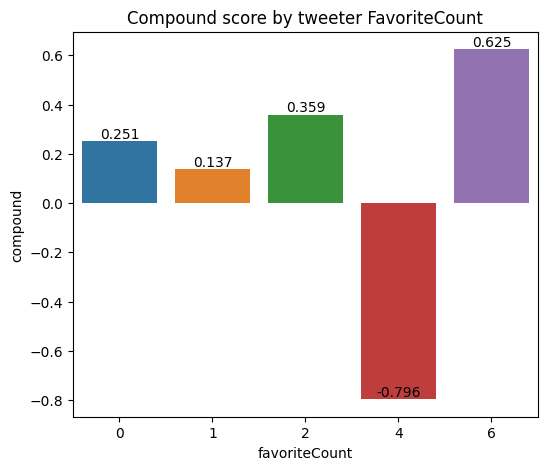

In [44]:
fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(1, 1, 1)
data = sns.barplot(data=data_results, x='favoriteCount', y='compound', ci=None)
ax.set_title('Compound score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'),
                 (i.get_x() + i.get_width() / 2., i.get_height()), ha =
'center', va = 'center',
                    xytext = (0, 5), textcoords = 'offset points')
plt.show()

Based on the graph above, the bar plot displays the compound scores for different values of favoriteCount. Here's how we can interpret the outcome based on the provided compound scores:

- **favoriteCount of 0 has a compound score of 0.251**: This indicates that tweets with 0 favorites have a positive compound sentiment score of 0.251 on average. It suggests that even though these tweets have not received any favorites, they still tend to have a generally positive sentiment.

- **favoriteCount of 1 has a compound score of 0.137**: Tweets with 1 favorite have a slightly lower average compound score of 0.137. This suggests that these tweets, though having a favorite, may have a slightly less positive sentiment compared to tweets with 0 favorites.

- **favoriteCount of 2 has a compound score of 0.359**: Tweets with 2 favorites have a higher average compound score of 0.359. This indicates that these tweets tend to have a more positive sentiment compared to tweets with fewer favorites.

- **favoriteCount of 4 has a compound score of -0.796**: Tweets with 4 favorites have a considerably negative average compound score of -0.796. It suggests that these tweets, despite receiving favorites, tend to have a predominantly negative sentiment.

- **favoriteCount of 6 has a compound score of 0.625**: Tweets with 6 favorites have a significantly positive average compound score of 0.625. This indicates that these tweets, which have gained a considerable number of favorites, tend to have a highly positive sentiment.

These insights help understand the relationship between the number of favorites (favoriteCount) and the sentiment expressed in the tweets (compound score). It suggests that higher favorite counts generally correspond to more positive sentiment, but there can be variations based on specific counts.






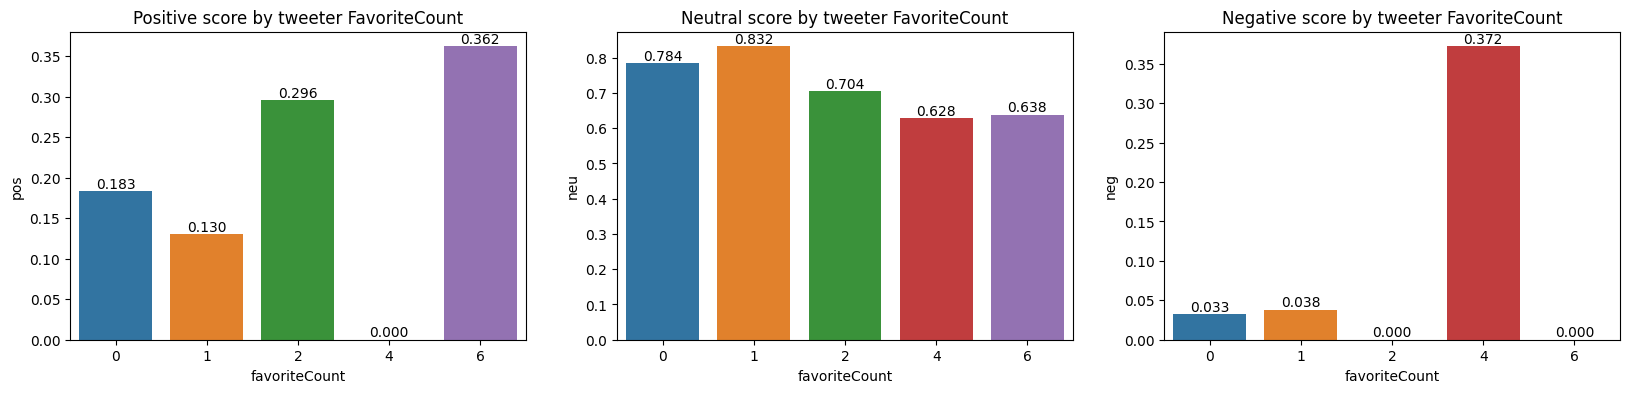

In [45]:
fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 3, 1)
data = sns.barplot(data=data_results, x='favoriteCount', y='pos', ci=None)
ax1.set_title('Positive score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax2 = fig.add_subplot(1, 3, 2)
data = sns.barplot(data=data_results, x='favoriteCount', y='neu', ci=None)
ax2.set_title('Neutral score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax3 = fig.add_subplot(1, 3, 3)
data = sns.barplot(data=data_results, x='favoriteCount', y='neg', ci=None)
ax3.set_title('Negative score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
plt.show()

Based on the graph above, here's we can interpret the highest and lowest positive, neutral, and negative scores for different favoriteCount values:

Positive Scores by tweeter Favorite Count graph:

- Highest Positive Score: favoriteCount of 6 has the highest positive score of 0.362. This indicates that tweets with 6 favorites tend to have a relatively higher positive sentiment.
- Lowest Positive Score: favoriteCount of 4 has the lowest positive score of 0. This suggests that tweets with 4 favorites have a neutral sentiment or a lack of positivity.

Neutral Scores by tweeter Favorite Count graph:

- Highest Neutral Score: favoriteCount of 1 has the highest neutral score of 0.832. This suggests that tweets with 1 favorite have a strong tendency towards a neutral sentiment.
- Lowest Neutral Score: favoriteCount of 4 has the lowest neutral score of 0.628. It indicates that tweets with 4 favorites have a slightly less neutral sentiment compared to other favoriteCount values.

Negative Scores by tweeter Favorite Count graph:

- Highest Negative Score: favoriteCount of 4 has the highest negative score of 0.372. This suggests that tweets with 4 favorites have a relatively higher negative sentiment.
- Lowest Negative Score: favoriteCount of 2 and 4 have the lowest negative scores of 0. This indicates that tweets with 2 and 4 favorites have a neutral sentiment or a lack of negativity.

These insights help understand the sentiment distribution across different favoriteCount values, indicating the varying sentiment trends based on the level of user engagement or popularity. 





In [46]:
data_results.mean()

favoriteCount    0.030000
neg              0.033054
neu              0.784080
pos              0.182850
compound         0.249114
dtype: float64

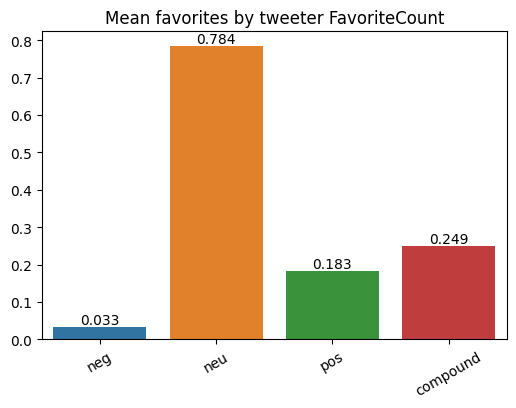

In [56]:
fig = plt.figure(figsize=(6, 4))

data_plot = data_results[['neg', 'neu', 'pos', 'compound']].mean()

ax = fig.add_subplot(1, 1, 1)
data = sns.barplot(x=data_plot.keys(), y=data_plot.values, ci=None)
ax.set_title('Mean favorites by tweeter FavoriteCount')
for i in data.get_xticklabels():
    i.set_rotation(30)
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'),
                 (i.get_x() + i.get_width() / 2., i.get_height()), ha =
'center', va = 'center',
                  xytext = (0, 5), textcoords = 'offset points')

Based on the graph above, we can interpret the mean values of the sentiment scores based on the favoriteCount:

- **Negative Score**: The mean negative score is 0.033, which is the lowest among all sentiment scores. It suggests that, on average, tweets with different favoriteCount values tend to have a relatively low negative sentiment.

- **Neutral Score**: The mean neutral score is 0.784, which is the highest among all sentiment scores. It indicates that, on average, tweets with different favoriteCount values tend to have a predominantly neutral sentiment.

- **Positive Score**: The mean positive score is 0.183. This suggests that, on average, tweets with different favoriteCount values tend to have a moderate positive sentiment.

- **Compound Score**: The mean compound score is 0.249. The compound score represents the overall sentiment of a tweet, combining both positive and negative aspects. A value close to 1 indicates highly positive sentiment, while a value close to -1 indicates highly negative sentiment. The mean compound score of 0.249 suggests that, on average, tweets with different favoriteCount values tend to have a slightly positive sentiment.

These insights provide an overview of the sentiment distribution across different favoriteCount values in the dataset.

### Step 5:  Emotion analysis

We can perform a deeper analysis by identifying the types of emotions contained in the
review text. To do this, we will use a library called `LeXmo`. The following code demonstrates
this.

In [48]:
pip install LeXmo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Next, we will try this library to analyze the
emotions contained in the product review text on tweeter that we have using the following
code.

In [49]:
from LeXmo import LeXmo

emotions = []

for words in tqdm(pos_tag_words[:1000], total=len(pos_tag_words[:1000])):
    emot = LeXmo.LeXmo(' '.join(words))
    emo = emot.pop('text', None)
    emotions.append(emot)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [35:13<00:00,  2.11s/it]


In the above code, we analyze the emotions in 1000 texts. This takes a considerable long amount of time to perform the analysis on the entire review text.

In [50]:
data_emotions = pd.DataFrame(emotions)
#data_emotions.sort_values(by='anger', ascending=False)

data_emot = pd.concat([dataset2[:1000], data_emotions], axis=1)
data_emot.head()

,screenName,text,favoriteCount,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,0,0.0,0.142857,0.0,0.0,0.142857,0.0,0.142857,0.0,0.000000,0.142857
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.142857,0.0,0.142857,0.000000


In [51]:
data_emot = pd.concat([dataset2[:1000], data_emotions], axis=1)
data_emot

,screenName,text,favoriteCount,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
0,DavidAc96,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
1,NRmalaa,"RT @agntecarter: i’m emotional, sorry!!\r\n\r\...",0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2,jijitsuu,saving these bingo cards for tomorrow \r\n©\r\...,0,0.000,0.142857,0.0,0.0,0.142857,0.000000,0.142857,0.0,0.000000,0.142857
3,SahapunB,RT @HelloBoon: Man these #AvengersEndgame ads ...,0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
4,stella22_97,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.142857,0.0,0.142857,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,abhijith_sai,Anyone interested for #AvengersEndgame 2D tick...,0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.090909,0.0,0.000000,0.000000
996,gustavooroger,RT @Avengers: .@Renner4Real hits the mark! #Ha...,0,0.125,0.000000,0.0,0.0,0.000000,0.125000,0.000000,0.0,0.000000,0.000000
997,00Sammy02,RT @MCU_Direct: The first NON-SPOILER #Avenger...,0,0.000,0.000000,0.0,0.0,0.000000,0.083333,0.000000,0.0,0.000000,0.000000
998,osakana630,RT @Marvel: These guys. @AnthonyMackie @chrish...,0,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.142857,0.0,0.142857,0.000000


The final step is to visualize the results for each emotion. The code remains the same as shown
above, just a slight modification is needed to update the data, x, and y values.

- Negative emotions graph

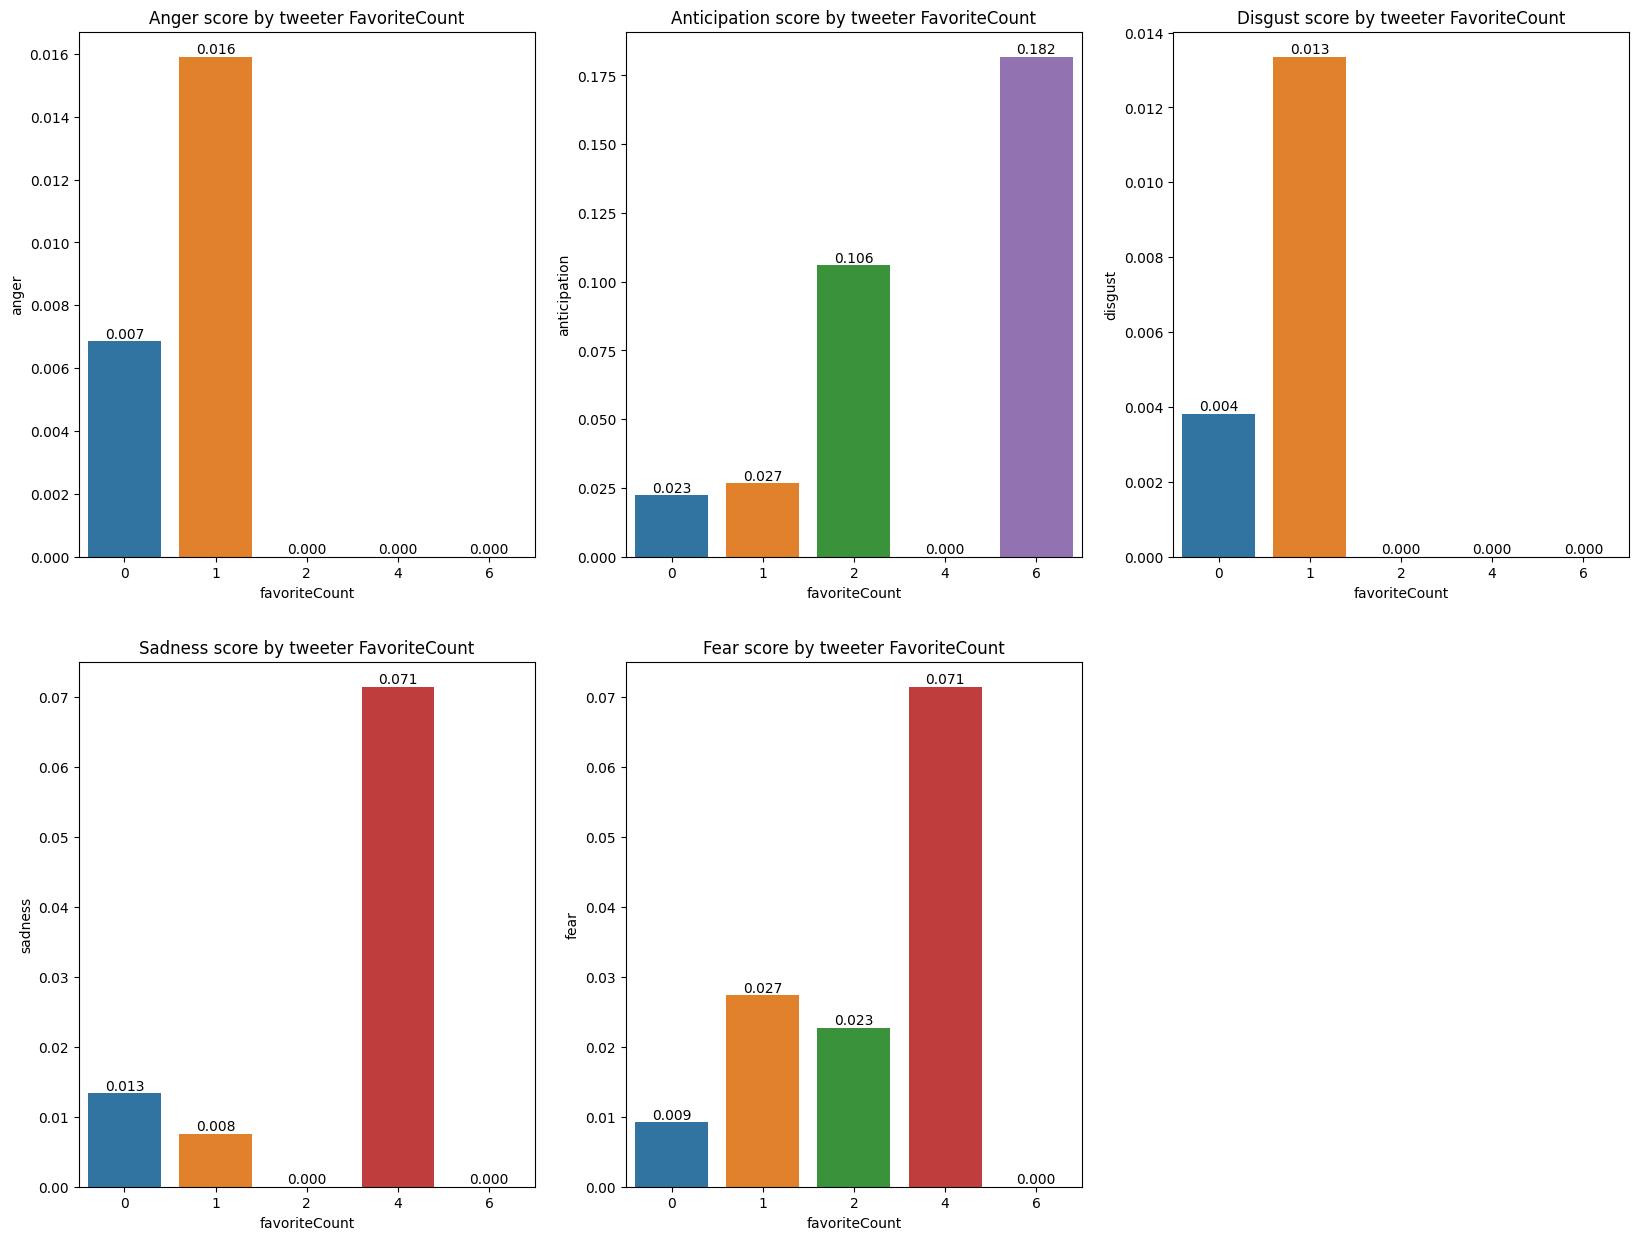

In [58]:
fig = plt.figure(figsize=(20, 15))

ax1 = fig.add_subplot(2, 3, 1)
data = sns.barplot(data=data_emot, x='favoriteCount', y='anger', ci=None)
ax1.set_title('Anger score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax2 = fig.add_subplot(2, 3, 2)
data = sns.barplot(data=data_emot, x='favoriteCount', y='anticipation', ci=None)
ax2.set_title('Anticipation score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax3 = fig.add_subplot(2, 3, 3)
data = sns.barplot(data=data_emot, x='favoriteCount', y='disgust', ci=None)
ax3.set_title('Disgust score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax4 = fig.add_subplot(2, 3, 4)
data = sns.barplot(data=data_emot, x='favoriteCount', y='sadness', ci=None)
ax4.set_title('Sadness score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')

ax4 = fig.add_subplot(2, 3, 5)
data = sns.barplot(data=data_emot, x='favoriteCount', y='fear', ci=None)
ax4.set_title('Fear score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
plt.show()

From the above negative emotion graphs,
- **Anger**: Tweets with a favoriteCount of 1 tend to express a relatively higher degree of anger, indicating that even tweets with minimal engagement can convey strong anger or frustration.

- **Anticipation**: Tweets with a favoriteCount of 6 exhibit a higher level of anticipation or expectation, suggesting that moderate engagement, as represented by the number of favorites, is associated with a sense of anticipation or excitement.

- **Sadness**: Tweets with a favoriteCount of 4 tend to express a stronger sentiment of sadness, implying that moderate engagement can be associated with content that evokes sadness or melancholy.

- **Fear**: Tweets with a favoriteCount of 4 exhibit a higher level of fear or anxiety, indicating that moderate engagement can also be linked to a sense of fear or concern.

- **Disgust**: The highest disgust score of 0.013 is associated with a favoriteCount of 1. This suggests that tweets with a single favorite can express a certain level of disgust, indicating content that provokes strong aversion or revulsion.

These highlight the relationship between the number of favorites and the intensity of various negative emotions expressed in tweets. 


- Positive emotions graph

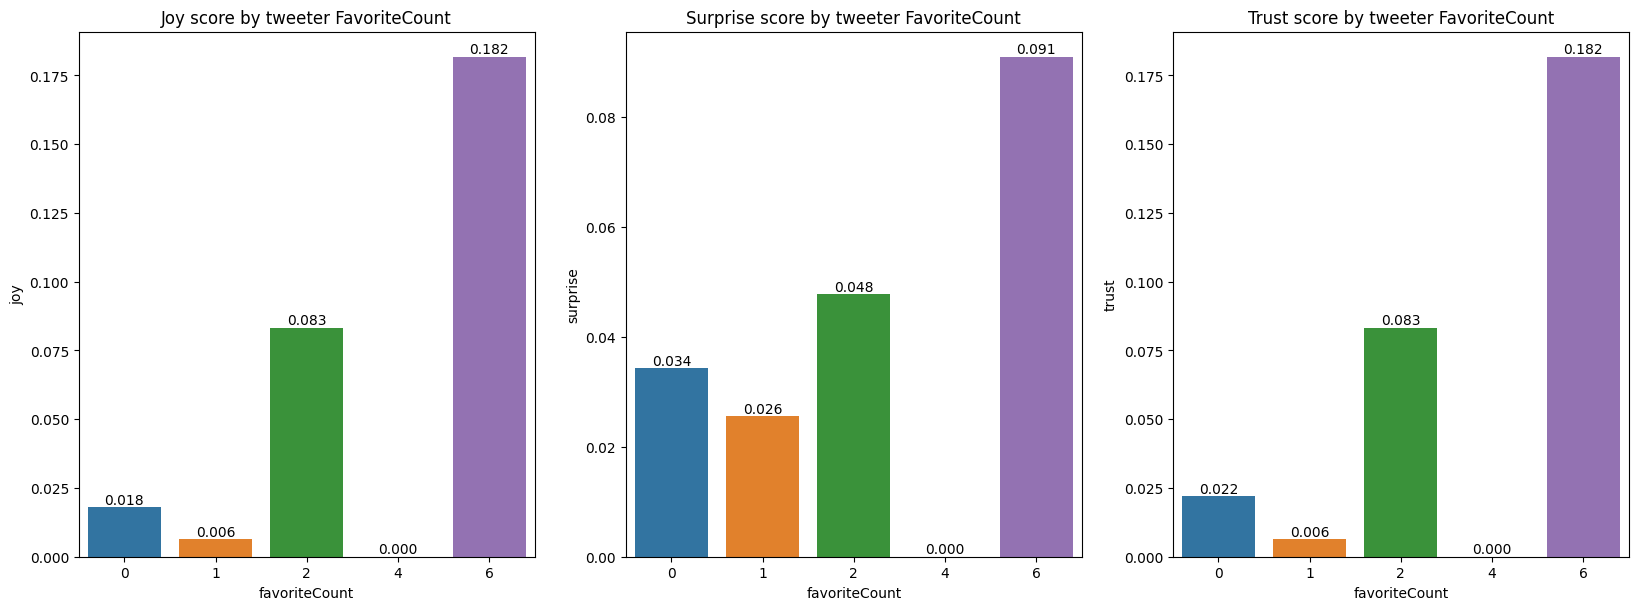

In [53]:
fig = plt.figure(figsize=(20, 15))

ax1 = fig.add_subplot(2, 3, 1)
data = sns.barplot(data=data_emot, x='favoriteCount', y='joy', ci=None)
ax1.set_title('Joy score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax2 = fig.add_subplot(2, 3, 2)
data = sns.barplot(data=data_emot, x='favoriteCount', y='surprise', ci=None)
ax2.set_title('Surprise score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')
    
ax3 = fig.add_subplot(2, 3, 3)
data = sns.barplot(data=data_emot, x='favoriteCount', y='trust', ci=None)
ax3.set_title('Trust score by tweeter FavoriteCount')
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha = 'center', va = 'center', 
                  xytext = (0, 5), textcoords = 'offset points')

From the above positive emotion graphs,
- **Joy**: The highest joy score of 0.182 is associated with a favoriteCount value of 6. This suggests that tweets with 6 favorites tend to convey a higher degree of joy or happiness in their content.

- **Surprise**: The highest surprise score of 0.091 is observed when the favoriteCount is 6. This indicates that tweets with 6 favorites tend to evoke a sense of surprise or astonishment among readers.

- **Trust**: The highest trust score of 0.182 is also linked to a favoriteCount value of 6. This suggests that tweets with 6 favorites tend to inspire a greater sense of trust or reliability among the audience.

These insights highlight the positive emotions associated with different levels of favoriteCount. Tweets that receive a moderate level of engagement, represented by a favoriteCount of 6, tend to convey higher levels of joy, surprise, and trust. It implies that tweets with a certain level of popularity or engagement have a greater potential to elicit positive emotions from readers.

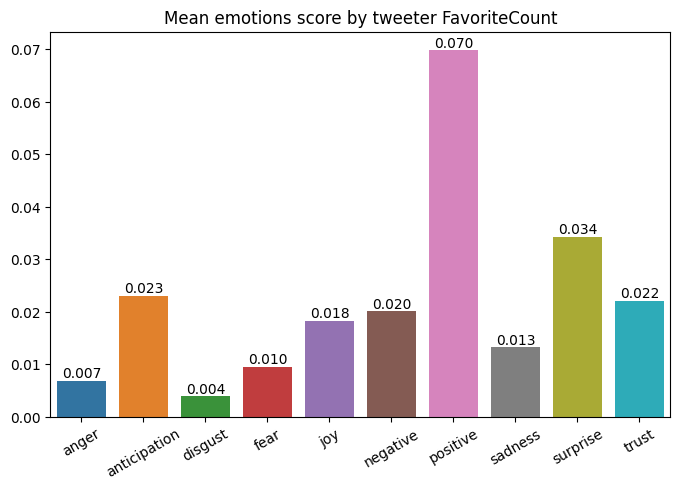

In [65]:
data_plot = data_emot.drop('favoriteCount', axis=1).mean()

fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 1, 1)
data = sns.barplot(x=data_plot.keys(), y=data_plot.values, ci=None)
ax1.set_title('Mean emotions score by tweeter FavoriteCount')

for i in data.get_xticklabels():
    i.set_rotation(30)
for i in data.patches:
    data.annotate(format(i.get_height(), '.3f'), 
                  (i.get_x() + i.get_width() / 2., i.get_height()), ha='center', va='center', 
                  xytext=(0, 5), textcoords='offset points')

plt.show()

Based on the graph above, the sentiment analysis of the tweet text related to the Avengers: Endgame movie reveals the following insights:
- **Positive sentiment**: The mean positive score is the highest among all the emotions analyzed, indicating that the majority of tweets about Avengers: Endgame have a positive sentiment. This suggests that the movie has generally received positive feedback and generated enthusiastic responses from Twitter users.

- **Surprise and anticipation**: The mean scores for surprise and anticipation are relatively higher compared to other emotions. This implies that Avengers: Endgame has successfully captivated audiences with unexpected plot twists and generated anticipation among fans. The surprises and unexpected elements of the movie have likely contributed to the positive sentiment surrounding it.

- **Other emotions**: The mean scores for emotions such as anger, fear, sadness, and disgust are relatively low. This suggests that negative emotions are less prevalent in tweets about Avengers: Endgame. The movie seems to have resonated more with positive emotions and excitement rather than negative or critical sentiments.

In conclusion, the sentiment analysis of tweet text related to Avengers: Endgame indicates a predominantly positive sentiment, with higher scores for positive emotions like joy and surprise. This suggests that the movie was well-received by Twitter users and generated a significant amount of enthusiasm and positive feedback. 




